# 01. Inspect Mahler Hand-DMFC Dataset

Goal:
- Load the Mahler Pong/DMFC dataset safely.
- Inspect top-level keys and core metadata.
- Identify columns needed for physics-based forward simulation.
- Visualize ball and paddle trajectories.
- Save a lightweight manifest for later deterministic / Monte Carlo simulation notebooks.

In [2]:
from pathlib import Path
import os
import sys
import gc
import types
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

# If this notebook is inside project-root/notebooks,
# project root is the parent directory.
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "hand_dmfc"
INTERIM_DIR = DATA_DIR / "interim"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

for d in [RAW_DIR, INTERIM_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MAHLER_PKL = RAW_DIR / "mahler_hand_dmfc_dataset_50ms.pkl"

print("PROJECT_ROOT:", PROJECT_ROOT.exists())
print("RAW_DIR:", RAW_DIR.exists())
print("INTERIM_DIR:", INTERIM_DIR.exists())
print("MAHLER_PKL exists:", MAHLER_PKL.exists())
if MAHLER_PKL.exists():
    print("MAHLER_PKL size MB:", MAHLER_PKL.stat().st_size / 1024**2)

PROJECT_ROOT: True
RAW_DIR: True
INTERIM_DIR: True
MAHLER_PKL exists: True
MAHLER_PKL size MB: 228.11734580993652


In [3]:
def patch_old_pandas_pickle():
    """
    Some older pandas pickles reference pandas.core.indexes.numeric.
    Newer pandas versions removed that module.
    This patch maps old index classes to pd.Index.
    """
    module_name = "pandas.core.indexes.numeric"
    
    if module_name not in sys.modules:
        numeric_module = types.ModuleType(module_name)
        numeric_module.Int64Index = pd.Index
        numeric_module.UInt64Index = pd.Index
        numeric_module.Float64Index = pd.Index
        sys.modules[module_name] = numeric_module


def load_pickle_compat(path: Path):
    patch_old_pandas_pickle()
    with open(path, "rb") as f:
        obj = pickle.load(f)
    return obj


assert MAHLER_PKL.exists(), f"File not found: {MAHLER_PKL}"

data = load_pickle_compat(MAHLER_PKL)

print("Loaded object type:", type(data))
if isinstance(data, dict):
    print("Number of top-level keys:", len(data))
    print("Top-level keys:")
    for k in data.keys():
        print(" -", k)

Loaded object type: <class 'dict'>
Number of top-level keys: 25
Top-level keys:
 - trial_meta
 - neural_meta
 - neural_responses
 - neural_responses_sh1
 - neural_responses_sh2
 - behavioral_responses
 - masks
 - ntr_vis
 - ntr_occ
 - meta
 - neural_idx_global
 - conds_ch_dict
 - reliable_neural_idx
 - neural_responses_reliable
 - neural_responses_reliable_sh1
 - neural_responses_reliable_sh2
 - neural_responses_reliable_FactorAnalysis_10
 - neural_responses_reliable_FactorAnalysis_10_sh1
 - neural_responses_reliable_FactorAnalysis_10_sh2
 - neural_responses_reliable_FactorAnalysis_20
 - neural_responses_reliable_FactorAnalysis_20_sh1
 - neural_responses_reliable_FactorAnalysis_20_sh2
 - neural_responses_reliable_FactorAnalysis_50
 - neural_responses_reliable_FactorAnalysis_50_sh1
 - neural_responses_reliable_FactorAnalysis_50_sh2


In [4]:
def summarize_value(name, value):
    if isinstance(value, pd.DataFrame):
        return {
            "key": name,
            "type": "DataFrame",
            "shape": value.shape,
            "detail": f"columns={len(value.columns)}"
        }
    elif isinstance(value, pd.Series):
        return {
            "key": name,
            "type": "Series",
            "shape": value.shape,
            "detail": f"name={value.name}"
        }
    elif isinstance(value, np.ndarray):
        return {
            "key": name,
            "type": "ndarray",
            "shape": value.shape,
            "detail": f"dtype={value.dtype}"
        }
    elif isinstance(value, dict):
        return {
            "key": name,
            "type": "dict",
            "shape": f"len={len(value)}",
            "detail": f"keys={list(value.keys())[:8]}"
        }
    elif isinstance(value, list):
        return {
            "key": name,
            "type": "list",
            "shape": f"len={len(value)}",
            "detail": f"first_type={type(value[0]).__name__ if len(value) else None}"
        }
    else:
        return {
            "key": name,
            "type": type(value).__name__,
            "shape": None,
            "detail": repr(value)[:80]
        }


summary_df = pd.DataFrame([
    summarize_value(k, v) for k, v in data.items()
])

summary_df

,key,type,shape,detail
0,trial_meta,DataFrame,"(10158, 87)",columns=87
1,neural_meta,DataFrame,"(518, 33)",columns=33
2,neural_responses,dict,len=2,"keys=['occ', 'vis']"
3,neural_responses_sh1,dict,len=2,"keys=['occ', 'vis']"
4,neural_responses_sh2,dict,len=2,"keys=['occ', 'vis']"
5,behavioral_responses,dict,len=2,"keys=['occ', 'vis']"
6,masks,dict,len=2,"keys=['occ', 'vis']"
7,ntr_vis,list,len=6,first_type=int
8,ntr_occ,list,len=6,first_type=int
9,meta,DataFrame,"(79, 88)",columns=88


In [5]:
trial_meta = data["trial_meta"].copy()
meta = data["meta"].copy()

print("trial_meta shape:", trial_meta.shape)
print("meta shape:", meta.shape)

display(trial_meta.head())
display(meta.head())

trial_meta shape: (10158, 87)
meta shape: (79, 88)


,py_meta_index,occ_alpha,trials_from_meta,ball_offset_x,ball_offset_y,ball_heading,ball_speed,success,failure,ignore,joystick_output,dataset_idx,experiment_idx,controller_on,py_x0,py_y0,py_heading0,py_speed,py_n_bounce,py_pad_size_mwk,py_pad_location_mwk,py_portal1_x,py_portal1_y,py_portal1_size_x,py_portal1_size_y,py_portal1_theta,py_portal2_x,py_portal2_y,py_portal2_size_x,py_portal2_size_y,py_portal2_theta,error,ball_y_final,ball_pos_x_from_mwk,ball_pos_y_from_mwk,paddle_pos_x_from_mwk,paddle_pos_y_from_mwk,photodiode_rectangle_pos_x_from_mwk,photodiode_rectangle_pos_y_from_mwk,session,session_date,b0,heading0,img_h,img_w,m0,n_bounce,pad,speed0,x0,y0,meta_index,n_bounce_correct,yf,x0_mworks,y0_mworks,yf_mworks,n_teleport,portal1_size_x,portal1_size_y,portal1_theta,portal1_x,portal1_y,portal2_size_x,portal2_size_y,portal2_theta,portal2_x,portal2_y,r,paddle_y,paddle_error,paddle_error_signed,proportion_cleaned_eye_positions,t_sync_on_mw,t_sync_on_oe,sync_match_r,sync_match_delta_err,sync_match_time_err,t_ball_on_relative,t_ball_on_offset_300_relative,t_photodiode_on_relative,t_photodiode_on_mw,t_photodiode_on_oe,t_ball_on_mw,t_ball_on_oe,t_ball_on_offset_300_mw,t_ball_on_offset_300_oe
0,273515.0,1.00,1.0,-1.6,7.8,26.577181,7.50,1.0,0.0,0.0,6.97,0.0,1.0,0.0,-1.6,7.8,26.577181,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.718458,6.251542,9.614858,6.306340,10.0,6.80,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,21.756443,0.463859,32.0,32.0,0.500265,1.0,8.0,0.50,13.44,28.48,273515.0,1.0,24.844538,-1.6,7.8,5.527836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.97,1.442164,1.442164,0.010603,2.755324e+08,42940.500000,1.0,0.139905,162.786017,355,55,26,2.755324e+08,42914.500000,2.755320e+08,42585.500000,2.755323e+08,42885.500000
1,377134.0,0.95,1.0,-0.2,-6.6,42.040268,7.50,1.0,0.0,0.0,2.89,0.0,1.0,0.0,-0.2,-6.6,42.040268,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.533361,2.356639,9.640471,2.272931,10.0,2.72,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,-8.698303,0.733741,32.0,32.0,0.901677,0.0,8.0,0.50,15.68,5.44,377134.0,0.0,20.172360,-0.2,-6.6,2.607725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.89,0.282275,0.282275,0.010603,2.755427e+08,53214.433333,1.0,0.139905,162.786017,364,64,35,2.755426e+08,53179.433333,2.755423e+08,52850.433333,2.755426e+08,53150.433333
2,187617.0,1.00,1.0,-3.0,-8.8,-28.510067,7.50,1.0,0.0,0.0,-2.38,0.0,1.0,0.0,-3.0,-8.8,-28.510067,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.389849,-3.769849,10.124887,-3.828534,10.0,-2.21,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,8.003652,-0.497595,32.0,32.0,-0.543183,1.0,8.0,0.50,11.20,1.92,187617.0,1.0,10.815516,-3.0,-8.8,-3.240303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.38,0.860303,0.860303,0.010603,2.755461e+08,56628.966667,1.0,0.139905,162.786017,367,67,38,2.755460e+08,56590.966667,2.755457e+08,56261.966667,2.755460e+08,56561.966667
3,77046.0,1.00,1.0,-5.6,-2.8,30.442953,7.50,0.0,1.0,0.0,2.38,0.0,1.0,0.0,-5.6,-2.8,30.442953,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,4.193585,6.573585,10.241714,6.510249,10.0,2.38,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,7.382559,0.531330,32.0,32.0,0.587705,1.0,8.0,0.50,7.04,11.52,77046.0,0.0,26.213726,-5.6,-2.8,6.383579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.38,4.003579,-4.003579,0.010603,2.755499e+08,60437.466667,1.0,0.139905,162.786017,358,58,29,2.755499e+08,60408.466667,2.755495e+08,60079.466667,2.755498e+08,60379.466667
4,248856.0,0.95,1.0,-1.8,-8.4,49.771812,11.25,0.0,1.0,0.0,2.72,0.0,1.0,0.0,-1.8,-8.4,49.771812,11.25,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,3.195214,5.915214,10.188274,5.772059,10.0,2.55,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,-12.949939,0.868682,32.0,32.0,1.182160,0.0,8.0,0.75,13.12,2.56,248856.0,0.0,24.891743,-1.8,-8.4,5.557339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.72,2.837339,-2.837339,

,occ_alpha,trials_from_meta,ball_offset_x,ball_offset_y,ball_heading,ball_speed,success,failure,ignore,joystick_output,dataset_idx,experiment_idx,controller_on,py_x0,py_y0,py_heading0,py_speed,py_n_bounce,py_pad_size_mwk,py_pad_location_mwk,py_portal1_x,py_portal1_y,py_portal1_size_x,py_portal1_size_y,py_portal1_theta,py_portal2_x,py_portal2_y,py_portal2_size_x,py_portal2_size_y,py_portal2_theta,error,ball_y_final,ball_pos_x_from_mwk,ball_pos_y_from_mwk,paddle_pos_x_from_mwk,paddle_pos_y_from_mwk,photodiode_rectangle_pos_x_from_mwk,photodiode_rectangle_pos_y_from_mwk,session_date,b0,heading0,img_h,img_w,m0,n_bounce,pad,speed0,x0,y0,meta_index,n_bounce_correct,yf,x0_mworks,y0_mworks,yf_mworks,n_teleport,portal1_size_x,portal1_size_y,portal1_theta,portal1_x,portal1_y,portal2_size_x,portal2_size_y,portal2_theta,portal2_x,portal2_y,r,paddle_y,paddle_error,paddle_error_signed,proportion_cleaned_eye_positions,t_sync_on_mw,t_sync_on_oe,sync_match_r,sync_match_delta_err,sync_match_time_err,t_ball_on_relative,t_ball_on_offset_300_relative,t_photodiode_on_relative,t_photodiode_on_mw,t_photodiode_on_oe,t_ball_on_mw,t_ball_on_oe,t_ball_on_offset_300_mw,t_ball_on_offset_300_oe,dx,dy,py_meta_index
py_meta_index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
29337,0.993310,1.0,-7.0,-8.8,26.577181,7.50,0.654930,0.190141,0.154930,-0.676408,0.0,1.0,0.0,-7.0,-8.8,26.577181,7.50,1.0,5.0,5.0,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.970806,-0.339536,9.881309,-0.354878,10.0,-0.578239,-22.0,12.0,2.021112e+07,-0.481270,0.463859,32.0,32.0,0.500265,1.0,8.0,0.50,4.80,1.92,29337.0,0.0,15.565790,-7.0,-8.8,-0.271381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.676408,1.016034,-0.405027,0.012477,2.739755e+08,4.265471e+06,1.0,0.167588,131.546784,362.514085,62.514085,47.253521,2.739755e+08,4.265424e+06,2.739752e+08,4.265109e+06,2.739755e+08,4.265409e+06,6.707494,3.355522,29337
55062,0.991935,1.0,-6.2,-4.4,-32.375839,7.50,0.612903,0.370968,0.016129,-3.937419,0.0,1.0,0.0,-6.2,-4.4,-32.375839,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.743791,-5.027263,9.917711,-5.093503,10.0,-3.868871,-22.0,12.0,2.021112e+07,12.814890,-0.565065,32.0,32.0,-0.634028,0.0,8.0,0.50,6.08,8.96,55062.0,1.0,8.919592,-6.2,-4.4,-4.425255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.937419,1.599905,0.487836,0.012379,2.630043e+08,4.079111e+06,1.0,0.167680,132.054942,362.758065,62.758065,47.266129,2.630043e+08,4.079064e+06,2.630039e+08,4.078749e+06,2.630042e+08,4.079049e+06,6.334154,-4.016030,55062
58244,0.991057,1.0,-6.2,4.2,-32.375839,7.50,0.699187,0.260163,0.040650,-5.499431,0.0,1.0,0.0,-6.2,4.2,-32.375839,7.50,1.0,5.0,5.0,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.348329,-6.019615,9.803604,-5.946732,10.0,-5.518781,-22.0,12.0,2.021112e+07,26.574890,-0.565065,32.0,32.0,-0.634028,1.0,8.0,0.50,6.08,22.72,58244.0,0.0,6.120408,-6.2,4.2,-6.174745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.499431,1.400058,0.675314,0.012438,2.580445e+08,4.162581e+06,1.0,0.168136,132.329554,362.674797,62.674797,47.008130,2.580445e+08,4.162534e+06,2.580441e+08,4.162218e+06,2.580444e+08,4.162518e+06,6.334154,-4.016030,58244
59920,0.992735,1.0,-6.2,8.6,-48.805369,11.25,0.410256,0.529915,0.059829,-7.019402,0.0,1.0,0.0,-6.2,8.6,-48.805369,11.25,1.0,5.0,5.0,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,2.427825,-9.404458,9.984960,-9.553176,10.0,-7.028120,-22.0,12.0,2.021112e+07,36.706441,-0.851814,32.0,32.0,-1.142507,1.0,8.0,0.75,6.08,29.76,59920.0,1.0,1.430946,-6.2,8.6,-9.105659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.019402,2.133472,2.086257,0.012194,2.671821e+08,4.219482e+06,1.0,0.166494,132.008104,361.991453,61.991453,46.170940,2.671820e+08,4.219436e+06,2.671817e+08,4.219120e+06,2.671820e+08,4.219420e+06,7.409463,-8.465362,59920
68220,0.991797,1.0,-5.8,-6.4,37.208054,7.50,0.742188,0.210938,0.046875,5.084062,0.0,1.0,0.0,-5.8,-6.4,37.208054,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-1

In [6]:
print("trial_meta columns:")
for i, c in enumerate(trial_meta.columns):
    print(f"{i:02d}: {c}")

print("\nmeta columns:")
for i, c in enumerate(meta.columns):
    print(f"{i:02d}: {c}")

trial_meta columns:
00: py_meta_index
01: occ_alpha
02: trials_from_meta
03: ball_offset_x
04: ball_offset_y
05: ball_heading
06: ball_speed
07: success
08: failure
09: ignore
10: joystick_output
11: dataset_idx
12: experiment_idx
13: controller_on
14: py_x0
15: py_y0
16: py_heading0
17: py_speed
18: py_n_bounce
19: py_pad_size_mwk
20: py_pad_location_mwk
21: py_portal1_x
22: py_portal1_y
23: py_portal1_size_x
24: py_portal1_size_y
25: py_portal1_theta
26: py_portal2_x
27: py_portal2_y
28: py_portal2_size_x
29: py_portal2_size_y
30: py_portal2_theta
31: error
32: ball_y_final
33: ball_pos_x_from_mwk
34: ball_pos_y_from_mwk
35: paddle_pos_x_from_mwk
36: paddle_pos_y_from_mwk
37: photodiode_rectangle_pos_x_from_mwk
38: photodiode_rectangle_pos_y_from_mwk
39: session
40: session_date
41: b0
42: heading0
43: img_h
44: img_w
45: m0
46: n_bounce
47: pad
48: speed0
49: x0
50: y0
51: meta_index
52: n_bounce_correct
53: yf
54: x0_mworks
55: y0_mworks
56: yf_mworks
57: n_teleport
58: portal1_siz

In [7]:
candidate_cols = [
    "meta_index",
    "x0", "y0", "yf",
    "x0_mworks", "y0_mworks", "yf_mworks",
    "heading0", "speed0", "n_bounce",
    "paddle_y", "paddle_error", "paddle_error_signed",
    "occ_alpha", "success", "failure", "ignore",
]

meta_cols_available = [c for c in candidate_cols if c in meta.columns]
trial_cols_available = [c for c in candidate_cols if c in trial_meta.columns]

print("Available in meta:")
print(meta_cols_available)

print("\nAvailable in trial_meta:")
print(trial_cols_available)

display(meta[meta_cols_available].head(10))
display(trial_meta[trial_cols_available].head(10))

Available in meta:
['meta_index', 'x0', 'y0', 'yf', 'x0_mworks', 'y0_mworks', 'yf_mworks', 'heading0', 'speed0', 'n_bounce', 'paddle_y', 'paddle_error', 'paddle_error_signed', 'occ_alpha', 'success', 'failure', 'ignore']

Available in trial_meta:
['meta_index', 'x0', 'y0', 'yf', 'x0_mworks', 'y0_mworks', 'yf_mworks', 'heading0', 'speed0', 'n_bounce', 'paddle_y', 'paddle_error', 'paddle_error_signed', 'occ_alpha', 'success', 'failure', 'ignore']


,meta_index,x0,y0,yf,x0_mworks,y0_mworks,yf_mworks,heading0,speed0,n_bounce,paddle_y,paddle_error,paddle_error_signed,occ_alpha,success,failure,ignore
py_meta_index,,,,,,,,,,,,,,,,,
29337,29337.0,4.80,1.92,15.565790,-7.0,-8.8,-0.271381,0.463859,0.50,1.0,-0.676408,1.016034,-0.405027,0.993310,0.654930,0.190141,0.154930
55062,55062.0,6.08,8.96,8.919592,-6.2,-4.4,-4.425255,-0.565065,0.50,0.0,-3.937419,1.599905,0.487836,0.991935,0.612903,0.370968,0.016129
58244,58244.0,6.08,22.72,6.120408,-6.2,4.2,-6.174745,-0.565065,0.50,1.0,-5.499431,1.400058,0.675314,0.991057,0.699187,0.260163,0.040650
59920,59920.0,6.08,29.76,1.430946,-6.2,8.6,-9.105659,-0.851814,0.75,1.0,-7.019402,2.133472,2.086257,0.992735,0.410256,0.529915,0.059829
68220,68220.0,6.72,5.76,25.110754,-5.8,-6.4,5.694221,0.649403,0.50,0.0,5.084062,1.293350,-0.610159,0.991797,0.742188,0.210938,0.046875
72780,72780.0,6.72,24.00,22.655879,-5.8,5.0,4.159924,0.565065,0.50,0.0,4.363769,1.886707,0.203845,0.990769,0.576923,0.353846,0.069231
77046,77046.0,7.04,11.52,26.213726,-5.6,-2.8,6.383579,0.531330,0.50,1.0,5.543115,1.439184,-0.840464,0.990984,0.680328,0.286885,0.032787
77944,77944.0,7.04,15.04,27.567282,-5.6,-0.6,7.229552,0.463859,0.50,0.0,6.173388,1.538090,-1.056163,0.991736,0.685950,0.272727,0.041322
90751,90751.0,7.68,5.44,26.793505,-5.2,-6.6,6.745941,0.716873,0.50,1.0,5.311825,1.642988,-1.434115,0.988492,0.682540,0.285714,0.031746


,meta_index,x0,y0,yf,x0_mworks,y0_mworks,yf_mworks,heading0,speed0,n_bounce,paddle_y,paddle_error,paddle_error_signed,occ_alpha,success,failure,ignore
0,273515.0,13.44,28.48,24.844538,-1.6,7.8,5.527836,0.463859,0.50,1.0,6.97,1.442164,1.442164,1.00,1.0,0.0,0.0
1,377134.0,15.68,5.44,20.172360,-0.2,-6.6,2.607725,0.733741,0.50,0.0,2.89,0.282275,0.282275,0.95,1.0,0.0,0.0
2,187617.0,11.20,1.92,10.815516,-3.0,-8.8,-3.240303,-0.497595,0.50,1.0,-2.38,0.860303,0.860303,1.00,1.0,0.0,0.0
3,77046.0,7.04,11.52,26.213726,-5.6,-2.8,6.383579,0.531330,0.50,1.0,2.38,4.003579,-4.003579,1.00,0.0,1.0,0.0
4,248856.0,13.12,2.56,24.891743,-1.8,-8.4,5.557339,0.868682,0.75,0.0,2.72,2.837339,-2.837339,0.95,0.0,1.0,0.0
5,59920.0,6.08,29.76,1.430946,-6.2,8.6,-9.105659,-0.851814,0.75,1.0,-9.52,0.414341,-0.414341,0.95,1.0,0.0,0.0
6,242380.0,12.80,13.76,29.535074,-2.0,-1.4,8.459421,0.784344,0.50,1.0,8.16,0.299421,-0.299421,1.00,1.0,0.0,0.0
7,251629.0,13.12,9.60,15.617229,-1.8,-4.0,-0.239232,-0.902417,0.50,1.0,-3.40,3.160768,-3.160768,1.00,0.0,1.0,0.0
8,270569.0,13.44,22.40,2.424816,-1.6,4.0,-8.484490,-0.902417,0.50,0.0,-7.99,0.494490,0.494490,1.00,1.0,0.0,0.0
9,163248.0,10.24,15.04,13.001945,-3.6,-0.6,-1.873784,-0.092772,0.50,1.0,-3.06,1.186216,-1.186216,1.00,1.0,0.0,0.0


In [8]:
print("Unique meta_index in trial_meta:", trial_meta["meta_index"].nunique())
print("Number of rows in meta:", len(meta))

trial_counts = (
    trial_meta
    .groupby("meta_index")
    .agg(
        n_trials=("meta_index", "size"),
        success_rate=("success", "mean"),
        failure_rate=("failure", "mean"),
        ignore_rate=("ignore", "mean"),
        mean_paddle_error=("paddle_error", "mean"),
        mean_paddle_error_signed=("paddle_error_signed", "mean"),
    )
    .reset_index()
)

display(trial_counts.head())
display(trial_counts.describe())

Unique meta_index in trial_meta: 79
Number of rows in meta: 79


,meta_index,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed
0,29337.0,142,0.654930,0.190141,0.154930,1.016034,-0.405027
1,55062.0,124,0.612903,0.370968,0.016129,1.599905,0.487836
2,58244.0,123,0.699187,0.260163,0.040650,1.400058,0.675314
3,59920.0,117,0.410256,0.529915,0.059829,2.133472,2.086257
4,68220.0,128,0.742188,0.210938,0.046875,1.293350,-0.610159


,meta_index,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,267992.518987,128.582278,0.618138,0.312088,0.069774,1.798395,-0.097582
std,126389.330509,15.877421,0.167947,0.158522,0.039679,0.798850,1.417473
min,29337.000000,106.000000,0.090226,0.093525,0.000000,0.642946,-4.850346
25%,181150.500000,123.000000,0.526040,0.187812,0.040986,1.284398,-0.890108
50%,258471.000000,127.000000,0.658730,0.285714,0.063492,1.599905,-0.104012
75%,380457.000000,131.000000,0.753986,0.408335,0.090231,2.049302,0.621323
max,469268.000000,251.000000,0.872881,0.827068,0.171233,4.934624,4.231297


In [9]:
behavioral = data["behavioral_responses"]

print("behavioral_responses keys:", behavioral.keys())

for mode in behavioral.keys():
    print(f"\n[{mode}]")
    for k, v in behavioral[mode].items():
        if isinstance(v, np.ndarray):
            print(f"{k:24s} shape={v.shape}, dtype={v.dtype}, nan_ratio={np.isnan(v).mean():.3f}")
        else:
            print(f"{k:24s} type={type(v)}")

behavioral_responses keys: dict_keys(['occ', 'vis'])

[occ]
ball_pos_x               shape=(79, 100), dtype=float64, nan_ratio=0.075
ball_pos_y               shape=(79, 100), dtype=float64, nan_ratio=0.075
paddle_pos_y             shape=(79, 100), dtype=float64, nan_ratio=0.010
joy                      shape=(79, 100), dtype=float64, nan_ratio=0.010
eye_v                    shape=(79, 100), dtype=float64, nan_ratio=0.010
eye_h                    shape=(79, 100), dtype=float64, nan_ratio=0.010
eye_dv                   shape=(79, 100), dtype=float64, nan_ratio=0.010
eye_dh                   shape=(79, 100), dtype=float64, nan_ratio=0.010
eye_dtheta               shape=(79, 100), dtype=float64, nan_ratio=0.010
eye_dspeed               shape=(79, 100), dtype=float64, nan_ratio=0.010
ball_pos_x_TRUE          shape=(79, 100), dtype=float64, nan_ratio=0.075
ball_pos_y_TRUE          shape=(79, 100), dtype=float64, nan_ratio=0.075
ball_pos_dx              shape=(79, 100), dtype=float64, nan_rat

In [10]:
masks = data["masks"]

print("masks keys:", masks.keys())

for mode in masks.keys():
    print(f"\n[{mode}]")
    keys = list(masks[mode].keys())
    print("number of mask keys:", len(keys))
    print("first 30 keys:")
    print(keys[:30])

masks keys: dict_keys(['occ', 'vis'])

[occ]
number of mask keys: 560
first 30 keys:
['pretrial_pad0', 'start_end_pad0', 'start_occ_pad0', 'occ_end_pad0', 'f_pad0', 'occ_pad0', 'start_pad0', 'start_pad0_roll0', 'start_pad0_roll1', 'start_pad0_roll2', 'start_pad0_roll3', 'start_pad0_roll4', 'start_pad0_roll5', 'start_pad0_roll6', 'start_pad0_roll7', 'start_pad0_roll8', 'start_pad0_roll9', 'start_pad0_roll10', 'start_pad0_roll11', 'start_pad0_roll12', 'start_pad0_roll13', 'start_pad0_roll14', 'start_pad0_roll15', 'start_pad0_roll16', 'start_pad0_roll17', 'start_pad0_roll18', 'start_pad0_roll19', 'start_pad0_roll20', 'start_pad0_roll21', 'start_pad0_roll22']

[vis]
number of mask keys: 6
first 30 keys:
['pretrial_pad0', 'start_end_pad0', 'start_occ_pad0', 'occ_end_pad0', 'f_pad0', 'occ_pad0']


In [11]:
mode = "occ"
important_masks = [
    "start_end_pad0",
    "start_occ_pad0",
    "occ_end_pad0",
    "occ_pad0",
    "f_pad0",
]

condition_i = 0

for mask_name in important_masks:
    if mask_name not in masks[mode]:
        print(f"{mask_name}: not found")
        continue
    
    arr = masks[mode][mask_name][condition_i]
    idx = np.where(np.isfinite(arr))[0]
    
    if len(idx) == 0:
        print(f"{mask_name}: empty")
    else:
        print(
            f"{mask_name:16s}: "
            f"start_idx={idx[0]:02d}, end_idx={idx[-1]:02d}, n={len(idx)}"
        )

start_end_pad0  : start_idx=06, end_idx=56, n=51
start_occ_pad0  : start_idx=06, end_idx=41, n=36
occ_end_pad0    : start_idx=41, end_idx=56, n=16
occ_pad0        : start_idx=41, end_idx=41, n=1
f_pad0          : start_idx=56, end_idx=56, n=1


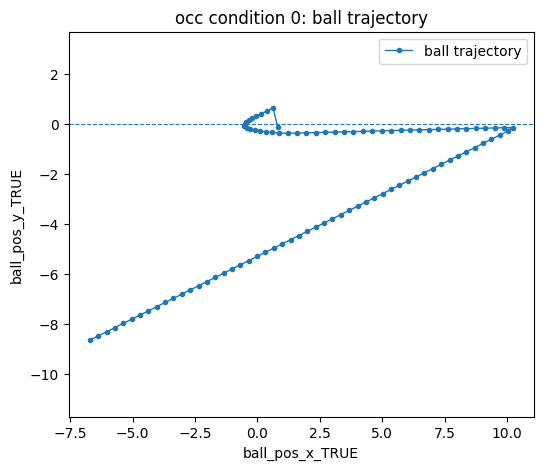

In [12]:
def get_array(d, preferred_keys):
    for k in preferred_keys:
        if k in d:
            return d[k], k
    raise KeyError(f"None of the keys found: {preferred_keys}")


mode = "occ"
condition_i = 0

br = behavioral[mode]

x_arr, x_key = get_array(br, ["ball_pos_x_TRUE", "ball_pos_x"])
y_arr, y_key = get_array(br, ["ball_pos_y_TRUE", "ball_pos_y"])
paddle_arr, paddle_key = get_array(br, ["paddle_pos_y"])

x = x_arr[condition_i]
y = y_arr[condition_i]
paddle_y = paddle_arr[condition_i]

valid = np.isfinite(x) & np.isfinite(y)

plt.figure(figsize=(6, 5))
plt.plot(x[valid], y[valid], marker="o", markersize=3, linewidth=1, label="ball trajectory")
plt.axhline(0, linewidth=0.8, linestyle="--")
plt.xlabel(x_key)
plt.ylabel(y_key)
plt.title(f"{mode} condition {condition_i}: ball trajectory")
plt.axis("equal")
plt.legend()
plt.show()

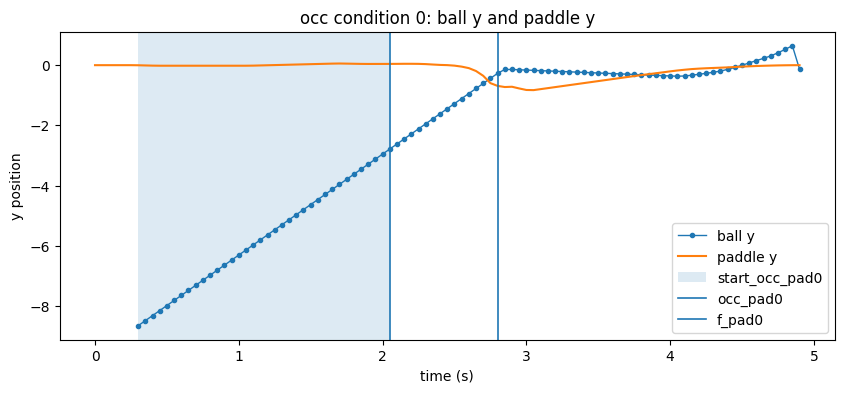

In [13]:
dt = 0.05
T = x_arr.shape[1]
t = np.arange(T) * dt

plt.figure(figsize=(10, 4))
plt.plot(t, y, marker="o", markersize=3, linewidth=1, label="ball y")
plt.plot(t, paddle_y, linewidth=1.5, label="paddle y")

# Mark important event times using masks
for mask_name, linestyle in [
    ("start_occ_pad0", "--"),
    ("occ_pad0", "-"),
    ("f_pad0", "-"),
]:
    if mask_name in masks[mode]:
        mask_row = masks[mode][mask_name][condition_i]
        idx = np.where(np.isfinite(mask_row))[0]
        if len(idx) > 0:
            if mask_name in ["occ_pad0", "f_pad0"]:
                plt.axvline(t[idx[0]], linestyle=linestyle, linewidth=1.2, label=mask_name)
            else:
                plt.axvspan(t[idx[0]], t[idx[-1]], alpha=0.15, label=mask_name)

plt.xlabel("time (s)")
plt.ylabel("y position")
plt.title(f"{mode} condition {condition_i}: ball y and paddle y")
plt.legend(loc="best")
plt.show()

In [14]:
def estimate_velocity_from_trace(x, y, start_idx=None, n_steps=8):
    """
    Estimate initial velocity from observed trajectory.
    Uses median step difference over the first few valid points.
    
    Returns:
        vx_step, vy_step
    where unit is position per time-bin, not per second.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    valid_idx = np.where(valid)[0]
    
    if len(valid_idx) < n_steps + 1:
        return np.nan, np.nan
    
    if start_idx is None:
        idx0 = valid_idx[0]
    else:
        idx0 = start_idx
    
    idx = np.arange(idx0, min(idx0 + n_steps + 1, len(x)))
    idx = idx[np.isfinite(x[idx]) & np.isfinite(y[idx])]
    
    if len(idx) < 2:
        return np.nan, np.nan
    
    dx = np.diff(x[idx])
    dy = np.diff(y[idx])
    
    return np.nanmedian(dx), np.nanmedian(dy)


condition_rows = []

x_all = x_arr
y_all = y_arr
paddle_all = paddle_arr

for ci in range(x_all.shape[0]):
    row = meta.iloc[ci].copy()
    
    x_trace = x_all[ci]
    y_trace = y_all[ci]
    paddle_trace = paddle_all[ci]
    
    valid = np.isfinite(x_trace) & np.isfinite(y_trace)
    valid_idx = np.where(valid)[0]
    
    first_idx = valid_idx[0] if len(valid_idx) else np.nan
    last_idx = valid_idx[-1] if len(valid_idx) else np.nan
    
    vx_trace_step, vy_trace_step = estimate_velocity_from_trace(
        x_trace, y_trace, start_idx=None, n_steps=8
    )
    
    # Parameter-based velocity.
    # Unit may not perfectly match trajectory step unit, so we only store it for comparison.
    if ("speed0" in meta.columns) and ("heading0" in meta.columns):
        vx_param = row["speed0"] * np.cos(row["heading0"])
        vy_param = row["speed0"] * np.sin(row["heading0"])
    else:
        vx_param = np.nan
        vy_param = np.nan
    
    # Event indices
    def first_mask_idx(mask_name):
        if mask_name not in masks[mode]:
            return np.nan
        m = masks[mode][mask_name][ci]
        idx = np.where(np.isfinite(m))[0]
        return idx[0] if len(idx) else np.nan
    
    occ_idx = first_mask_idx("occ_pad0")
    final_idx = first_mask_idx("f_pad0")
    
    condition_rows.append({
        "condition_i": ci,
        "meta_index": row["meta_index"] if "meta_index" in row else np.nan,
        
        "x0_mworks": row["x0_mworks"] if "x0_mworks" in row else np.nan,
        "y0_mworks": row["y0_mworks"] if "y0_mworks" in row else np.nan,
        "yf_mworks": row["yf_mworks"] if "yf_mworks" in row else np.nan,
        
        "x0_raw": row["x0"] if "x0" in row else np.nan,
        "y0_raw": row["y0"] if "y0" in row else np.nan,
        "yf_raw": row["yf"] if "yf" in row else np.nan,
        
        "heading0": row["heading0"] if "heading0" in row else np.nan,
        "speed0": row["speed0"] if "speed0" in row else np.nan,
        "n_bounce": row["n_bounce"] if "n_bounce" in row else np.nan,
        
        "vx_param": vx_param,
        "vy_param": vy_param,
        "vx_trace_step": vx_trace_step,
        "vy_trace_step": vy_trace_step,
        
        "first_valid_idx": first_idx,
        "last_valid_idx": last_idx,
        "occ_idx": occ_idx,
        "final_idx": final_idx,
        "horizon_steps_occ_to_final": final_idx - occ_idx if np.isfinite(occ_idx) and np.isfinite(final_idx) else np.nan,
        
        "ball_y_at_occ": y_trace[int(occ_idx)] if np.isfinite(occ_idx) else np.nan,
        "ball_y_at_final": y_trace[int(final_idx)] if np.isfinite(final_idx) else np.nan,
        "paddle_y_at_final": paddle_trace[int(final_idx)] if np.isfinite(final_idx) else np.nan,
    })

condition_manifest = pd.DataFrame(condition_rows)

display(condition_manifest.head(10))
display(condition_manifest.describe())

,condition_i,meta_index,x0_mworks,y0_mworks,yf_mworks,x0_raw,y0_raw,yf_raw,heading0,speed0,n_bounce,vx_param,vy_param,vx_trace_step,vy_trace_step,first_valid_idx,last_valid_idx,occ_idx,final_idx,horizon_steps_occ_to_final,ball_y_at_occ,ball_y_at_final,paddle_y_at_final
0,0,29337.0,-7.0,-8.8,-0.271381,4.80,1.92,15.565790,0.463859,0.50,1.0,0.447166,0.223701,0.335375,0.167776,6,98,41,56,15,-2.787992,-0.271351,-0.688933
1,1,55062.0,-6.2,-4.4,-4.425255,6.08,8.96,8.919592,-0.565065,0.50,0.0,0.422277,-0.267735,0.316708,-0.200801,6,98,41,56,15,-8.066386,-5.085590,-3.723874
2,2,58244.0,-6.2,4.2,-6.174745,6.08,22.72,6.120408,-0.565065,0.50,1.0,0.422277,-0.267735,0.316708,-0.200802,6,98,41,56,15,-2.995164,-6.007161,-5.745208
3,3,59920.0,-6.2,8.6,-9.105659,6.08,29.76,1.430946,-0.851814,0.75,1.0,0.493964,-0.564357,0.370473,-0.423268,6,98,36,49,13,-4.450462,-9.766393,-7.246475
4,4,68220.0,-5.8,-6.4,5.694221,6.72,5.76,25.110754,0.649403,0.50,0.0,0.398222,0.302356,0.298667,0.226767,6,98,42,58,16,1.952503,5.580769,5.144827
5,5,72780.0,-5.8,5.0,4.159924,6.72,24.00,22.655879,0.565065,0.50,0.0,0.422277,0.267735,0.316708,0.200801,6,98,39,55,16,7.865287,4.685771,4.827982
6,6,77046.0,-5.6,-2.8,6.383579,7.04,11.52,26.213726,0.531330,0.50,1.0,0.431067,0.253340,0.323300,0.190005,6,98,38,53,15,3.438277,6.288354,5.616862
7,7,77944.0,-5.6,-0.6,7.229552,7.04,15.04,27.567282,0.463859,0.50,0.0,0.447166,0.223701,0.335375,0.167776,6,98,37,51,14,4.740794,7.089659,6.332453
8,8,90751.0,-5.2,-6.6,6.745941,7.68,5.44,26.793505,0.716873,0.50,1.0,0.376932,0.328515,0.282699,0.246387,6,98,42,59,17,2.475338,6.663910,5.357863
9,9,93053.0,-5.2,-1.2,-6.283723,7.68,14.08,5.946043,-0.649403,0.50,0.0,0.398222,-0.302356,0.298667,-0.226767,6,98,39,56,17,-8.872451,-6.920723,-6.741161


,condition_i,meta_index,x0_mworks,y0_mworks,yf_mworks,x0_raw,y0_raw,yf_raw,heading0,speed0,n_bounce,vx_param,vy_param,vx_trace_step,vy_trace_step,first_valid_idx,last_valid_idx,occ_idx,final_idx,horizon_steps_occ_to_final,ball_y_at_occ,ball_y_at_final,paddle_y_at_final
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.0,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,39.000000,267992.518987,-2.022785,-0.762025,-0.495280,12.763544,14.780759,15.207553,0.021245,0.481013,0.481013,0.378837,0.008472,0.284146,0.008876,6.0,97.493671,30.822785,49.329114,18.506329,-0.605614,-0.505324,-0.628778
std,22.949219,126389.330509,2.112232,5.478450,5.272863,3.379572,8.765520,8.436580,0.664014,0.096178,0.502832,0.082258,0.302313,0.061702,0.224123,0.0,3.161764,6.726830,10.618950,5.843852,5.303557,5.400964,4.965906
min,0.000000,29337.000000,-7.000000,-9.000000,-9.449771,4.800000,1.600000,0.880366,-1.104829,0.250000,0.000000,0.186217,-0.564357,0.139663,-0.423268,6.0,78.000000,19.000000,34.000000,13.000000,-9.792950,-9.766393,-7.246475
25%,19.500000,181150.500000,-3.200000,-6.100000,-5.442918,10.880000,6.240000,7.291331,-0.615668,0.500000,0.000000,0.350922,-0.278323,0.263192,-0.208742,6.0,98.000000,24.500000,41.500000,15.000000,-4.468215,-5.397608,-5.832213
50%,39.000000,258471.000000,-1.800000,-1.200000,-0.409547,13.120000,14.080000,15.344725,0.446992,0.500000,0.000000,0.408194,0.144376,0.306145,0.108282,6.0,98.000000,31.000000,48.000000,16.000000,-1.426503,-0.951839,-1.275821
75%,58.500000,380457.000000,-0.200000,4.000000,4.229764,15.680000,22.400000,22.767622,0.607234,0.500000,1.000000,0.439367,0.264155,0.329525,0.192718,6.0,98.000000,37.000000,55.000000,19.000000,3.135593,4.697695,4.725959
max,78.000000,469268.000000,0.800000,8.600000,8.563056,17.280000,29.760000,29.700890,1.189167,0.750000,1.000000,0.497850,0.572609,0.373387,0.429456,6.0,98.000000,42.000000,76.000000,35.000000,9.631794,8.901912,6.920324


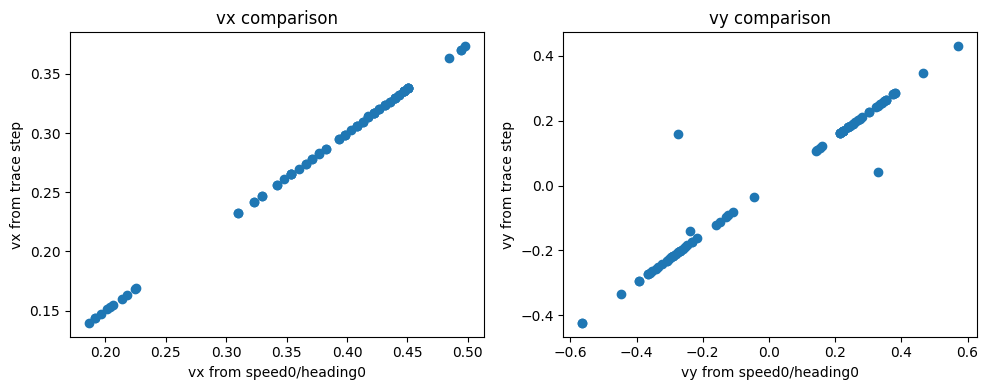

Correlation vx:
               vx_param  vx_trace_step
vx_param       1.000000       0.999998
vx_trace_step  0.999998       1.000000

Correlation vy:
               vy_param  vy_trace_step
vy_param       1.000000       0.977839
vy_trace_step  0.977839       1.000000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(condition_manifest["vx_param"], condition_manifest["vx_trace_step"])
axes[0].set_xlabel("vx from speed0/heading0")
axes[0].set_ylabel("vx from trace step")
axes[0].set_title("vx comparison")

axes[1].scatter(condition_manifest["vy_param"], condition_manifest["vy_trace_step"])
axes[1].set_xlabel("vy from speed0/heading0")
axes[1].set_ylabel("vy from trace step")
axes[1].set_title("vy comparison")

plt.tight_layout()
plt.show()

print("Correlation vx:")
print(condition_manifest[["vx_param", "vx_trace_step"]].corr())

print("\nCorrelation vy:")
print(condition_manifest[["vy_param", "vy_trace_step"]].corr())

In [16]:
condition_manifest = condition_manifest.merge(
    trial_counts,
    on="meta_index",
    how="left"
)

display(condition_manifest.head())
display(condition_manifest[[
    "n_trials",
    "success_rate",
    "failure_rate",
    "ignore_rate",
    "mean_paddle_error",
    "mean_paddle_error_signed"
]].describe())

,condition_i,meta_index,x0_mworks,y0_mworks,yf_mworks,x0_raw,y0_raw,yf_raw,heading0,speed0,n_bounce,vx_param,vy_param,vx_trace_step,vy_trace_step,first_valid_idx,last_valid_idx,occ_idx,final_idx,horizon_steps_occ_to_final,ball_y_at_occ,ball_y_at_final,paddle_y_at_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed
0,0,29337.0,-7.0,-8.8,-0.271381,4.80,1.92,15.565790,0.463859,0.50,1.0,0.447166,0.223701,0.335375,0.167776,6,98,41,56,15,-2.787992,-0.271351,-0.688933,142,0.654930,0.190141,0.154930,1.016034,-0.405027
1,1,55062.0,-6.2,-4.4,-4.425255,6.08,8.96,8.919592,-0.565065,0.50,0.0,0.422277,-0.267735,0.316708,-0.200801,6,98,41,56,15,-8.066386,-5.085590,-3.723874,124,0.612903,0.370968,0.016129,1.599905,0.487836
2,2,58244.0,-6.2,4.2,-6.174745,6.08,22.72,6.120408,-0.565065,0.50,1.0,0.422277,-0.267735,0.316708,-0.200802,6,98,41,56,15,-2.995164,-6.007161,-5.745208,123,0.699187,0.260163,0.040650,1.400058,0.675314
3,3,59920.0,-6.2,8.6,-9.105659,6.08,29.76,1.430946,-0.851814,0.75,1.0,0.493964,-0.564357,0.370473,-0.423268,6,98,36,49,13,-4.450462,-9.766393,-7.246475,117,0.410256,0.529915,0.059829,2.133472,2.086257
4,4,68220.0,-5.8,-6.4,5.694221,6.72,5.76,25.110754,0.649403,0.50,0.0,0.398222,0.302356,0.298667,0.226767,6,98,42,58,16,1.952503,5.580769,5.144827,128,0.742188,0.210938,0.046875,1.293350,-0.610159


,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,128.582278,0.618138,0.312088,0.069774,1.798395,-0.097582
std,15.877421,0.167947,0.158522,0.039679,0.798850,1.417473
min,106.000000,0.090226,0.093525,0.000000,0.642946,-4.850346
25%,123.000000,0.526040,0.187812,0.040986,1.284398,-0.890108
50%,127.000000,0.658730,0.285714,0.063492,1.599905,-0.104012
75%,131.000000,0.753986,0.408335,0.090231,2.049302,0.621323
max,251.000000,0.872881,0.827068,0.171233,4.934624,4.231297


In [17]:
manifest_path_parquet = INTERIM_DIR / "mahler_condition_manifest.parquet"
manifest_path_csv = INTERIM_DIR / "mahler_condition_manifest.csv"

try:
    condition_manifest.to_parquet(manifest_path_parquet, index=False)
    print("Saved parquet:", manifest_path_parquet)
except Exception as e:
    print("Parquet save failed. Saving CSV instead.")
    print("Reason:", repr(e))
    condition_manifest.to_csv(manifest_path_csv, index=False)
    print("Saved CSV:", manifest_path_csv)

Parquet save failed. Saving CSV instead.
Reason: ImportError("Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.\nA suitable version of pyarrow or fastparquet is required for parquet support.\nTrying to import the above resulted in these errors:\n - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.\n - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.")
Saved CSV: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\interim\mahler_condition_manifest.csv


In [19]:
trajectory_npz_path = INTERIM_DIR / "mahler_occ_trajectory_arrays.npz"

save_dict = {
    "ball_pos_x": x_arr,
    "ball_pos_y": y_arr,
    "paddle_pos_y": paddle_arr,
}

# Important masks
for mask_name in important_masks:
    if mask_name in masks[mode]:
        save_dict[f"mask_{mask_name}"] = masks[mode][mask_name]

np.savez_compressed(trajectory_npz_path, **save_dict)

# print("Saved trajectory arrays:", trajectory_npz_path)
print("Size MB:", trajectory_npz_path.stat().st_size / 1024**2)

Size MB: 0.16155529022216797


In [20]:
# Reload manifest
if manifest_path_parquet.exists():
    manifest_reloaded = pd.read_parquet(manifest_path_parquet)
else:
    manifest_reloaded = pd.read_csv(manifest_path_csv)

arrays_reloaded = np.load(trajectory_npz_path)

print("manifest shape:", manifest_reloaded.shape)
print("arrays keys:", list(arrays_reloaded.keys()))

display(manifest_reloaded.head())

manifest shape: (79, 29)
arrays keys: ['ball_pos_x', 'ball_pos_y', 'paddle_pos_y', 'mask_start_end_pad0', 'mask_start_occ_pad0', 'mask_occ_end_pad0', 'mask_occ_pad0', 'mask_f_pad0']


,condition_i,meta_index,x0_mworks,y0_mworks,yf_mworks,x0_raw,y0_raw,yf_raw,heading0,speed0,n_bounce,vx_param,vy_param,vx_trace_step,vy_trace_step,first_valid_idx,last_valid_idx,occ_idx,final_idx,horizon_steps_occ_to_final,ball_y_at_occ,ball_y_at_final,paddle_y_at_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed
0,0,29337.0,-7.0,-8.8,-0.271381,4.80,1.92,15.565790,0.463859,0.50,1.0,0.447166,0.223701,0.335375,0.167776,6,98,41,56,15,-2.787992,-0.271351,-0.688933,142,0.654930,0.190141,0.154930,1.016034,-0.405027
1,1,55062.0,-6.2,-4.4,-4.425255,6.08,8.96,8.919592,-0.565065,0.50,0.0,0.422277,-0.267735,0.316708,-0.200801,6,98,41,56,15,-8.066386,-5.085590,-3.723874,124,0.612903,0.370968,0.016129,1.599905,0.487836
2,2,58244.0,-6.2,4.2,-6.174745,6.08,22.72,6.120408,-0.565065,0.50,1.0,0.422277,-0.267735,0.316708,-0.200802,6,98,41,56,15,-2.995164,-6.007161,-5.745208,123,0.699187,0.260163,0.040650,1.400058,0.675314
3,3,59920.0,-6.2,8.6,-9.105659,6.08,29.76,1.430946,-0.851814,0.75,1.0,0.493964,-0.564357,0.370473,-0.423268,6,98,36,49,13,-4.450462,-9.766393,-7.246475,117,0.410256,0.529915,0.059829,2.133472,2.086257
4,4,68220.0,-5.8,-6.4,5.694221,6.72,5.76,25.110754,0.649403,0.50,0.0,0.398222,0.302356,0.298667,0.226767,6,98,42,58,16,1.952503,5.580769,5.144827,128,0.742188,0.210938,0.046875,1.293350,-0.610159
